No dependencies on external functions to see the whole process

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import LogNorm

# memmap load photon maps

In [2]:
filename = f"../data/photon_maps/run{70:03d}_module{0:02d}.dat"
photon_maps = np.memmap(filename, shape = (18089, 200, 128, 512), mode='r')

photon maps that are loaded in here is fast and a memmory mapped array for the full run. i.e. remains on disk unless you copy the array into memory

# load filters

In [3]:
def load_train_sum(run, module):
    # todo: actually save properly
    return np.load(f'../data/small_data/train_sum_run{run:03d}_module{module:02d}.npy')

In [4]:
def get_filter_per_train():
    # TODO: generalize and write function actually
    # want a fast way to filter out the trains we dont want.
    # returns a boolean array of length ntrains
    # this can be integrated image, xgm, etc for each train
    avg_train = load_train_sum(run=70, module=0).mean(axis=-1)
    min_thresh = np.percentile(avg_train, 33)
    max_thresh = np.percentile(avg_train, 66)
    
    filt_abs = (avg_train <= max_thresh) & (avg_train >= min_thresh)
    return filt_abs

In [5]:
%%time
filt_abs = get_filter_per_train()

print(f'filter shape: {filt_abs.shape}, dtype:{filt_abs.dtype}, \
trains used: {filt_abs.sum()}  ({filt_abs.mean()*100:.2f}%), ')

filter shape: (18089,), dtype:bool, trains used: 5969  (33.00%), 
CPU times: user 3.73 ms, sys: 17.2 ms, total: 21 ms
Wall time: 153 ms


In [6]:
%%time
def get_pulse_resolved_reference():
    #TODO: generalize and determine what we want
    # this is what will be used to determine the relative intensity between two pulses
    # to filter within each train
    # return is an array float array of (total trains, number pulses),
    # no filter of each train since it is fast and small anyways
    return load_train_sum(run=70, module=0)
     
pulse_ref = get_pulse_resolved_reference()
pulse_ref.shape, pulse_ref.dtype

CPU times: user 1 ms, sys: 13.3 ms, total: 14.3 ms
Wall time: 13.6 ms


((18089, 200), dtype('float64'))

# single delay test

In [7]:
import numba as nb

@nb.jit(nopython=True, parallel=True, cache=True)
def get_relative_intensity_filter(arr, dt, thresh, pulses_per_train=200):
    # changed relative to probablities as of 3/28/25
    # only takes in one train
    # returns valid pulse pairs in given train
    out = np.full((pulses_per_train - dt), True)
    for j in nb.prange(pulses_per_train - dt):
        left = arr[j]
        right = arr[j + dt]
        out[j] = np.abs(left - right) / ((left + right) / 2) < thresh
    return out

In [8]:
%%time
train_index = 0
dt = 7

filt_rel = get_relative_intensity_filter(pulse_ref[train_index], dt, thresh=0.05)

CPU times: user 155 ms, sys: 139 ms, total: 294 ms
Wall time: 510 ms


In [343]:
def add_two_trains_delayed(arr, delay, mask):
    valid_pulse_pairs = np.nonzero([mask])[0]
    N_valid_pairs = len(valid_pulse_pairs)
    out = np.zeros((N_valid_pairs, *arr.shape[1:]), dtype=arr.dtype)
    for i in range(N_valid_pairs):
        out[i] = arr[i] + arr[i + delay]     
    return out

In [344]:
pm = photon_maps[10]

In [345]:
%%time
two_sum = add_two_trains_delayed(pm, dt, mask=filt_rel)

CPU times: user 2.16 ms, sys: 21 µs, total: 2.19 ms
Wall time: 1.62 ms


In [290]:
%%time
valid_train_indices = np.nonzero(filt_abs)[0]

CPU times: user 655 µs, sys: 0 ns, total: 655 µs
Wall time: 598 µs


In [17]:
@nb.jit(nopython=True, parallel=True)
def bincount(arr, max_photons):
    """
    Apply np.bincount to each pixel in the chunk.

    Parameters:
    arr (numpy array): Input chunk with shape (n, x, y).
    max_photons (int, optional): Maximum number of photons. Defaults to 19.

    Returns:
    numpy array: Output array with shape (x, y, max_photons+1).
    """
    n_sample, n_i, n_j = arr.shape
    out = np.zeros((n_i, n_j, max_photons+1), dtype=np.uint64)
    for i in nb.prange(n_i):
        for j in nb.prange(n_j):
            for x in nb.prange(n_sample):
                if arr[x, i, j] <= max_photons:
                    out[i, j, arr[x, i, j]] += 1
    return out

In [268]:
counts = bincount(two_sum.astype(np.uint), 50)

In [269]:
counts.shape

(128, 128, 51)

In [114]:
#%%prun -D ../data/debug/test.prof
dt = 1
MAX_PHOTONS = 30
counts = np.zeros((128,128, 31), dtype=np.uint)
denom = 0
for train_index in tqdm(valid_train_indices):
    filt_rel = get_relative_intensity_filter(pulse_ref[train_index], dt, thresh=0.05)
    pm = photon_maps[train_index, :, :128,:128]
    two_sum = add_two_trains_delayed(pm, dt, mask=filt_rel)
    counts += bincount(two_sum, MAX_PHOTONS)
    denom += len(two_sum)
pmfs = counts / denom

  0%|          | 0/5969 [00:00<?, ?it/s]

# with all delays

In [340]:
def photon_map_to_pmf_single_delay(photon_maps, valid_train_indices, pulse_ref, thresh, dt, max_photons):
    # photon_maps: memmap numpy array
    # valid_train_indices: array of trains that are usable (reference first axis of memmap photon_maps)
    # pulse ref: intensity filer to compare different pulses to according to thresh within train
    # thresh: threshold for pulse_ref
    # dt: delay
    # max photons: cutoff for total number of photons to save for the integration of two pulses
    # note: if it is not desired to load in entire shape of photon_maps, you must pass in a slice of photon maps
    # or it wont be a memmap array and therefore will make a copy

    counts = np.zeros((*photon_maps.shape[-2:], max_photons+1), dtype=np.uint)
    denom = 0
    kbar_numer = np.zeros(photon_maps.shape[-2:])
    for train_index in valid_train_indices:
        filt_rel = get_relative_intensity_filter(pulse_ref[train_index], dt, thresh=thresh)
        pm = photon_maps[train_index]
        if dt == 0:
            # right now for a relative intensity filter single pulse contrast doesn't filter
            # by anything since it is all self reference. Additionally it is impossible to
            # have odd numbered pulses if adding to itself so stats are funky/ unphysical in fitting.
            two_sum = pm
        else:
            two_sum = add_two_trains_delayed(pm, dt, mask=filt_rel)
        
        counts += bincount(two_sum, max_photons)
        kbar_numer += two_sum.sum(axis=0)
        denom += len(two_sum)
    pmf = counts / denom
    kbar = kbar_numer / denom
    return pmf, kbar

In [367]:
smd_ind = valid_train_indices[-328:]

In [364]:
smd_ind.shape

(328,)

In [365]:
max_photons = 30
pmfs = np.zeros((200, *pm_smd.shape[-2:], max_photons+1))
kbars = np.zeros((200, *pm_smd.shape[-2:]))
for dt in tqdm(range(200)):
    pmfs[dt], kbars[dt] = photon_map_to_pmf_single_delay(photon_maps=pm_smd, valid_train_indices=smd_ind,
                                                        pulse_ref=pulse_ref, thresh=0.05, dt=dt, max_photons=max_photons)

  0%|          | 0/200 [00:00<?, ?it/s]

In [366]:
np.save('../data/debug/photon_maps_to_pm_last_1000_valid.npy', pmfs)
np.save('../data/debug/photon_maps_to_pm_loop_kbar_last_1000_valid.npy', kbars)

# lazy:)

In [368]:
def neg_binom(k_bar, k, M):
    import scipy.special as sp
    """
    Calculate the negative binomial distribution for photon-arrival events. Details can
    be found in Speckle Phenomena in Optics: Theory and Applications by Goodman. See section
    on speckle at low light levels.

    Parameters:
    k_bar (float): The average number of photons.
    k (int): The number of photons.
    M (int): The number of modes influencing the measurement.

    Returns:
    float: The probability of k photons arriving given an average incident intensity
    (k_bar) and number of modes (M) .
    """
    # Calculate the prefactor using the log-gamma function for numerical stability
    prefactor = np.exp(sp.loggamma(k + M) - sp.loggamma(M) - sp.loggamma(k+1))
    postfactor = ((k_bar/(k_bar+M))**k)*((M/(k_bar+M))**M) # no this is not a factor....

    return prefactor * postfactor

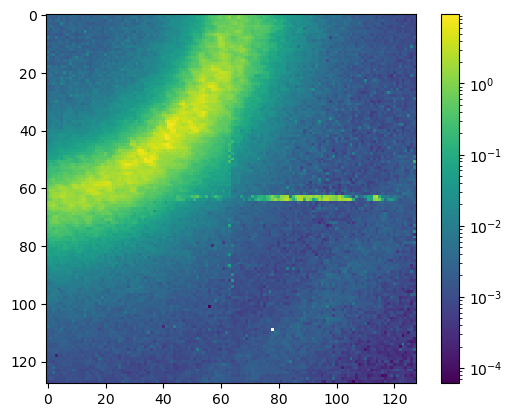

In [369]:
img = kbars[0]
plt.figure()
plt.imshow(img, norm=LogNorm(), interpolation='nearest')
plt.colorbar()
plt.show()

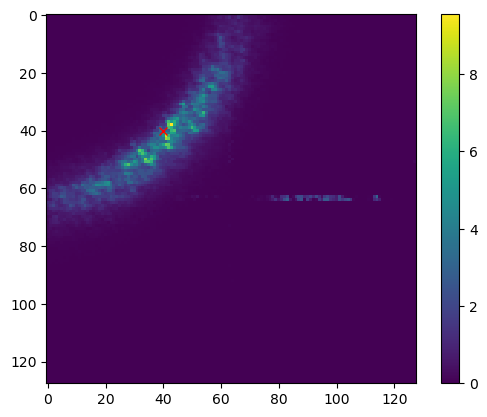

In [370]:
loc = (40, 40)

plt.figure()
plt.imshow(img, interpolation='nearest')
plt.plot(loc[1], loc[0], 'rx')
plt.colorbar()
plt.show()

In [133]:
pmfs.shape, kbar.shape

((200, 128, 128, 31), (200, 128, 128))

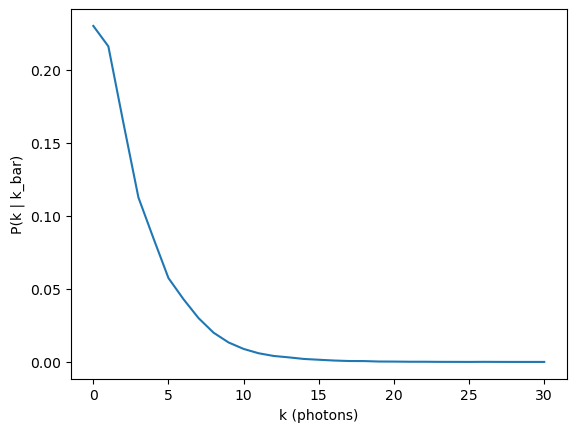

In [386]:
# delay, row, col
loc = (0, 45, 45)

y = pmfs[*loc]
x = kbars[*loc]
k = np.arange(len(y))

plt.figure()
plt.plot(k, y)
plt.ylabel('P(k | k_bar)')
plt.xlabel('k (photons)')
plt.show()

In [389]:
from lmfit import Model, Parameters

model = Model(neg_binom, independent_vars=['k_bar', 'k'])
params = Parameters()
params.add('M', value=4, min=0.001, max=100000)
result = model.fit(data=y, k_bar=x, k=k, **params)

M = result.best_values['M']
pk_fit = neg_binom(x, k, M=M)

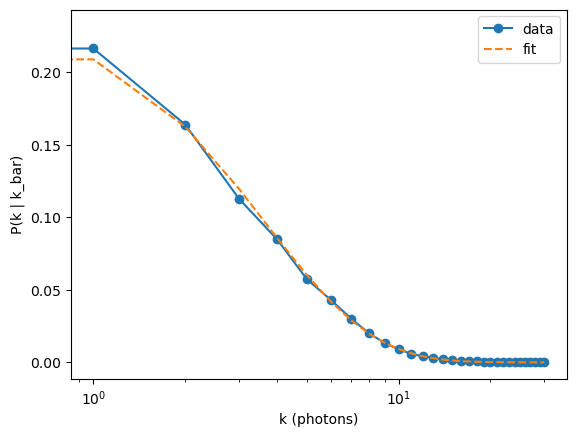

In [393]:
plt.figure()
plt.plot(k, y, '-o', label='data')
plt.plot(pk_fit, '--', label='fit')
plt.ylabel('P(k | k_bar)')
plt.xlabel('k (photons)')
plt.legend()
plt.semilogx()
plt.show()

In [ ]:
out = []
for dt in range(200):
    loc = (dt, 45, 45)
    result = model.fit(data=y, k_bar=x, k=k, **params)

In [ ]:
# delay, row, col
loc = (0, 45, 45)

y = pmfs[*loc]
x = kbars[*loc]
k = np.arange(len(y))

plt.figure()
plt.plot(k, y)
plt.ylabel('P(k | k_bar)')
plt.xlabel('k (photons)')
plt.show()